# C00：全流程教学与总控 Notebook

本 Notebook 意在全面地展示课题的推进课程，也可用于项目内部复现实验，同时也是我个人学习的路径记录。

它把 C01-C22 串成一条完整主线：

1. 数据审计：C01-C03
2. 字段探索：C04-C11
3. 数据清洗与构造：C12
4. 子集划分、可视化与统计检验：C13-C17
5. 净效应、稳健性、匹配诊断与机制解释：C18-C22

Notebook 内容按阶段推进，每一段都试图讲清三个问题：

1. 这一段为什么选择该方法处理
2. 脚本究竟处理了哪些对象
3. 输出结果会如何影响下一阶段的方法选择

Notebook 默认通过外部项目解释器运行各个脚本，因此即使当前内核不是最理想状态，也能稳定复现项目流程。

## 0) 环境、路径与执行模式准备

这一格负责三件事：

- 识别项目根目录与 Codes/ 目录
- 优先绑定推荐解释器 C:/Code/Anaconda3/envs/muc-qmjh/python.exe
- 设置演示可用的 fast mode，与正式复现实验使用的 full mode

说明：

- fast mode 会降低少数高耗时脚本的 bootstrap 次数，便于课堂展示
- full mode 保留脚本默认口径，更适合正式结果复现
- Notebook 里的脚本执行仍以项目脚本为准，Notebook 主要承担总控与展示角色

In [ ]:
from pathlib import Path
import sys

cwd = Path.cwd()
project_root = cwd.parent if cwd.name == "Codes" else cwd
codes_dir = project_root / "Codes"

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
if str(codes_dir) not in sys.path:
    sys.path.append(str(codes_dir))

print(f"Current working directory: {cwd}")
print(f"Project root: {project_root}")
print(f"Codes dir exists: {codes_dir.exists()} | {codes_dir}")

Current working directory: d:\Files\MUC-QMJH\Codes
Project root: d:\Files\MUC-QMJH
Codes dir exists: True | d:\Files\MUC-QMJH\Codes


In [ ]:
import csv
import subprocess
from IPython.display import Image, display

raw_data_dir = project_root / "Data" / "lmarena-aiarena-human-preference-140k" / "Data"
raw_file_paths = [raw_data_dir / f"train-{i:05d}-of-00007.parquet" for i in range(7)]
integrated_file = project_root / "Data" / "integrated_data" / "integrated_data.parquet"
optimized_file = project_root / "Data" / "optimized_data" / "optimized_data.parquet"

preferred_python = Path("C:/Code/Anaconda3/envs/muc-qmjh/python.exe")
python_executable = preferred_python if preferred_python.exists() else Path(sys.executable)

FAST_MODE = True
C20_BOOTSTRAP = 10 if FAST_MODE else 30
C22_BOOTSTRAP = 10 if FAST_MODE else 50
C22_MAX_N = 20000 if FAST_MODE else None


def _print_captured_output(text: str, max_lines: int = 120) -> None:
    lines = text.splitlines()
    if len(lines) <= max_lines:
        print(text)
        return
    print("\n".join(lines[:max_lines]))
    print(f"\n... output truncated: showing first {max_lines} of {len(lines)} lines ...")



def run_project_script(script_name: str, args: list[str] | None = None, max_output_lines: int = 120) -> str:
    command = [str(python_executable), str(codes_dir / script_name)]
    if args:
        command.extend(args)

    print("=" * 80)
    print("Running:", " ".join(command))
    print("=" * 80)
    completed = subprocess.run(
        command,
        cwd=project_root,
        text=True,
        capture_output=True,
        encoding="utf-8",
    )
    if completed.stdout:
        _print_captured_output(completed.stdout, max_lines=max_output_lines)
    if completed.stderr:
        print("[stderr]")
        _print_captured_output(completed.stderr, max_lines=max_output_lines)
    if completed.returncode != 0:
        raise RuntimeError(f"{script_name} failed with exit code {completed.returncode}")
    return completed.stdout



def show_text_file(relative_path: str, max_lines: int = 40) -> None:
    file_path = project_root / relative_path
    print("=" * 80)
    print(file_path)
    print("=" * 80)
    if not file_path.exists():
        print("File not found.")
        return
    text = file_path.read_text(encoding="utf-8", errors="replace")
    _print_captured_output(text, max_lines=max_lines)



def show_csv_file(relative_path: str, max_rows: int = 8) -> None:
    file_path = project_root / relative_path
    print("=" * 80)
    print(file_path)
    print("=" * 80)
    if not file_path.exists():
        print("File not found.")
        return
    with file_path.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        for row_index, row in enumerate(reader):
            print(row)
            if row_index >= max_rows:
                break



def show_image_file(relative_path: str, width: int = 900) -> None:
    file_path = project_root / relative_path
    print(file_path)
    if not file_path.exists():
        print("Image not found.")
        return
    display(Image(filename=str(file_path), width=width))



def run_parquet_preview(relative_path: str, columns: list[str] | None = None, head: int = 8) -> None:
    target = project_root / relative_path
    preview_code = "\n".join([
        "from pathlib import Path",
        "import pandas as pd",
        f"file_path = Path(r'{target.as_posix()}')",
        f"columns = {repr(columns)}",
        f"head = {int(head)}",
        "df = pd.read_parquet(file_path)",
        "print(f'Shape: {df.shape}')",
        "print('Columns:')",
        "print(list(df.columns))",
        "print('Preview:')",
        "if columns is not None:",
        "    print(df[columns].head(head).to_string(index=False))",
        "else:",
        "    print(df.head(head).to_string(index=False))",
    ])
    completed = subprocess.run(
        [str(python_executable), "-c", preview_code],
        cwd=project_root,
        text=True,
        capture_output=True,
        encoding="utf-8",
    )
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print("[stderr]")
        print(completed.stderr)
    if completed.returncode != 0:
        raise RuntimeError(f"Parquet preview failed with exit code {completed.returncode}")


print("Kernel Python executable:", Path(sys.executable))
print("Project Python executable:", python_executable)
print("Fast mode:", FAST_MODE)
print("C20 bootstrap:", C20_BOOTSTRAP)
print("C22 bootstrap:", C22_BOOTSTRAP)
print("C22 max_n:", C22_MAX_N)
print("\nRaw parquet file paths:")
for p in raw_file_paths:
    print(" -", p)
print("\nIntegrated file target:", integrated_file)
print("Optimized file target:", optimized_file)

Kernel Python executable: c:\Code\Anaconda3\python.exe
Project Python executable: C:\Code\Anaconda3\envs\muc-qmjh\python.exe
Fast mode: True
C20 bootstrap: 10
C22 bootstrap: 10
C22 max_n: 20000

Raw parquet file paths:
 - d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00000-of-00007.parquet
 - d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00001-of-00007.parquet
 - d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00002-of-00007.parquet
 - d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00003-of-00007.parquet
 - d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00004-of-00007.parquet
 - d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00005-of-00007.parquet
 - d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00006-of-00007.parquet

Integrated file target: d:\Files\MUC-QMJH\Data\integrated_data\integrated_data.parquet
Optimiz

## 1) C01：验证 session 跨分片完整性

教学要点：
- 如果同一 `evaluation_session_id` 出现在多个分片，后续按会话分析会混乱。
- C01 的目标是确认：分片之间没有会话重叠。

In [3]:
run_project_script("C01_verify_session_integrity.py")

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C01_verify_session_integrity.py
验证数据分割后的会话完整性
处理文件 1/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00000-of-00007.parquet
  读取成功，数据形状: (19377, 14)
  发现 18599 种不同的 evaluation_session_id
处理文件 2/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00001-of-00007.parquet
  读取成功，数据形状: (19377, 14)
  发现 18627 种不同的 evaluation_session_id
处理文件 3/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00002-of-00007.parquet
  读取成功，数据形状: (19376, 14)
  发现 17973 种不同的 evaluation_session_id
处理文件 4/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00003-of-00007.parquet
  读取成功，数据形状: (19376, 14)
  发现 18746 种不同的 evaluation_session_id
处理文件 5/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00004-of-00007.parquet
  读取成功，数据形状: (19376, 14)
  发现 18604 种不同的 evaluation_session_id
处理文件 6/7: d:\Files\MUC-QMJH\Data\lmare

'================================================================================\n验证数据分割后的会话完整性\n================================================================================\n处理文件 1/7: d:\\Files\\MUC-QMJH\\Data\\lmarena-aiarena-human-preference-140k\\Data\\train-00000-of-00007.parquet\n  读取成功，数据形状: (19377, 14)\n  发现 18599 种不同的 evaluation_session_id\n================================================================================\n处理文件 2/7: d:\\Files\\MUC-QMJH\\Data\\lmarena-aiarena-human-preference-140k\\Data\\train-00001-of-00007.parquet\n  读取成功，数据形状: (19377, 14)\n  发现 18627 种不同的 evaluation_session_id\n================================================================================\n处理文件 3/7: d:\\Files\\MUC-QMJH\\Data\\lmarena-aiarena-human-preference-140k\\Data\\train-00002-of-00007.parquet\n  读取成功，数据形状: (19376, 14)\n  发现 17973 种不同的 evaluation_session_id\n================================================================================\n处理文件 4/7: d:\\Files\\MUC-QMJH\\Data\\lmaren

## 2) C02：整合 7 个原始分片

教学要点：
- 将分片统一合并后，后续分析口径一致。
- 输出文件：`Data/integrated_data/integrated_data.parquet`。

In [4]:
run_project_script("C02_integrate_data.py")
print("\nIntegrated file exists:", integrated_file.exists())

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C02_integrate_data.py
整合各个parquet文件
处理文件 1/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00000-of-00007.parquet
  读取成功，数据形状: (19377, 14)
处理文件 2/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00001-of-00007.parquet
  读取成功，数据形状: (19377, 14)
处理文件 3/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00002-of-00007.parquet
  读取成功，数据形状: (19376, 14)
处理文件 4/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00003-of-00007.parquet
  读取成功，数据形状: (19376, 14)
处理文件 5/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00004-of-00007.parquet
  读取成功，数据形状: (19376, 14)
处理文件 6/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00005-of-00007.parquet
  读取成功，数据形状: (19376, 14)
处理文件 7/7: d:\Files\MUC-QMJH\Data\lmarena-aiarena-human-preference-140k\Data\train-00006-of-00007.parquet
  读

## 2.1) 快速预览合并后的总表

教学要点：

- C02 的价值不只是“把文件拼起来”，而是统一后续研究口径。
- 这一格建议现场展示：总表的行列规模、关键字段、以及一行记录大致长什么样。

推荐讲法：先告诉学生“这一张表不是最终分析表，而是 Phase 2 还会继续清洗和优化的中间表”。

In [5]:
preview_code = "\n".join([
    "from pathlib import Path",
    "import pandas as pd",
    f"file_path = Path(r'{integrated_file.as_posix()}')",
    "df = pd.read_parquet(file_path)",
    "print(f'Integrated shape: {df.shape}')",
    "print('\\nPreview columns:')",
    "print(list(df.columns))",
    "print('\\nHead preview:')",
    "print(df[['id', 'evaluation_session_id', 'evaluation_order', 'winner', 'language']].head(8).to_string(index=False))",
])

completed = subprocess.run(
    [str(python_executable), "-c", preview_code],
    cwd=project_root,
    text=True,
    capture_output=True,
    encoding="utf-8",
)
if completed.stdout:
    print(completed.stdout)
if completed.stderr:
    print("[stderr]")
    print(completed.stderr)
if completed.returncode != 0:
    raise RuntimeError(f"Preview command failed with exit code {completed.returncode}")

Integrated shape: (135634, 14)

Preview columns:
['id', 'model_a', 'model_b', 'winner', 'evaluation_session_id', 'evaluation_order', 'conversation_a', 'conversation_b', 'full_conversation', 'conv_metadata', 'category_tag', 'language', 'is_code', 'timestamp']

Head preview:
                                  id                evaluation_session_id  evaluation_order   winner language
c4b9710c-8d64-4bee-a0b0-94637ae4cc65 a333a685-37f9-474d-b703-f079d8329552                 1  model_a       en
7c44a466-fd07-4992-9764-176b75746a07 73e84b7b-d158-4d2d-9a7f-56286ec14564                 1      tie       pl
46e04015-dc69-442a-8b37-3caea0336541 8132faad-e9c2-48ef-b608-718504d9ab75                 1 both_bad       en
4a4380bb-bbdb-495f-8e09-39a08d88a28f d1c66159-2b6f-4c09-a090-165520330cc3                 3  model_a       en
ce23b477-d72c-4048-a01d-c3d26c80ad71 8c2ce87c-650c-4777-8503-65b5f797ec50                 1  model_b       de
40f981ca-cca6-4e2a-a48c-d10d51884efe 578a880d-7c6d-440d-aa5f-19154

## 3) C03：验证 session 内 evaluation_order 一致性

教学要点：
- 检查是否有缺号（如 1,2,4）或重号（同一会话出现两个 order=2）。
- 这一步决定多轮会话数据是否可直接用于后续分析。

In [6]:
run_project_script("C03_verify_order_consistency.py")

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C03_verify_order_consistency.py
验证原数据的 evaluation_order 字段的完整性
正在分析文件: d:\Files\MUC-QMJH\Data\integrated_data\integrated_data.parquet
  读取成功，数据形状: (135634, 14)
验证结果
evaluation_session_id 总数: 115372
单个 session 最大记录数: 25
全局 evaluation_order 最大值: 28
可能存在缺失 order 的 session 数量: 8912
可能存在重复 order 的 session 数量: 13
  结论: 存在 session 的记录数、最大 order 或唯一 order 数不一致，可能存在 order 缺失或重复。

[stderr]
0.03s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.



'================================================================================\n验证原数据的 evaluation_order 字段的完整性\n================================================================================\n正在分析文件: d:\\Files\\MUC-QMJH\\Data\\integrated_data\\integrated_data.parquet\n  读取成功，数据形状: (135634, 14)\n================================================================================\n验证结果\n================================================================================\nevaluation_session_id 总数: 115372\n单个 session 最大记录数: 25\n全局 evaluation_order 最大值: 28\n可能存在缺失 order 的 session 数量: 8912\n可能存在重复 order 的 session 数量: 13\n  结论: 存在 session 的记录数、最大 order 或唯一 order 数不一致，可能存在 order 缺失或重复。\n'

## 4) Phase 1 小结

建议把这一阶段概括成三句话：

1. 原始数据不是可以直接做统计的平面表，而是带有 Session、Order、Turn 层级的复杂对象。
2. 在正式分析前，必须先确认会话是否跨分片、总表是否需要统一整合、会话内部的 evaluation_order 是否一致。
3. 只有当研究对象的结构可靠时，后面的清洗、检验和建模才有意义。

下面开始把 Phase 2 到 Phase 5 一并串进来，形成可独立展示的全流程 Notebook。

# Phase 2：字段探索与原始数据理解（C04-C11）

这一阶段的目标不是立刻做统计结论，而是回答一个更基础的问题：
integrated_data 这张总表里的关键字段到底是什么意思，它们是否可信，是否存在明显异常。

课堂讲法建议：

1. 先讲字段层级：session、order、turn、model、role、content、token、category_tag
2. 再讲“为什么不能跳过字段探索直接建模”
3. 最后说明：C04-C11 的输出主要是理解性报告，而不是最终研究结论

In [7]:
for script_name, report_path in [
    ("C04_touch_session.py", "Reports/R01_session_report.txt"),
    ("C05_touch_order.py", "Reports/R02_order_report.txt"),
    ("C06_touch_turn.py", "Reports/R03_turn_report.txt"),
]:
    run_project_script(script_name, max_output_lines=80)
    show_text_file(report_path, max_lines=30)

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C04_touch_session.py
分析原数据的 evaluation_session_id 字段
正在分析文件: d:\Files\MUC-QMJH\Data\integrated_data\integrated_data.parquet
  读取成功，数据形状: (135634, 14)
  发现 115372 种不同的 evaluation_session_id 字段值
  发现 13206 种多次出现的 evaluation_session_id 字段值
生成分析报告...
分析报告已保存至: d:\Files\MUC-QMJH\Reports\R01_session_report.txt

[stderr]
0.03s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.

d:\Files\MUC-QMJH\Reports\R01_session_report.txt
evaluation_session_id 分析报告

1. 基本信息
----------------------------------------
分析文件: d:\Files\MUC-QMJH\Data\integrated_data\integrated_data.parquet
数据总行数: 135634
evaluation_session_id 唯一值数量: 115372
多次出现的 evaluation_session_id 数量: 13206

2. 出现次数分布
-------

In [8]:
for script_name, report_path in [
    ("C07_touch_model.py", "Reports/R04_model_report.txt"),
    ("C08_touch_role.py", "Reports/R05_role_report.txt"),
    ("C09_touch_cont.py", "Reports/R06_cont_report.txt"),
    ("C10_verify_token_correction.py", "Reports/R07_token_report.txt"),
    ("C11_touch_category_tag.py", "Reports/R08_category_tag_report.txt"),
]:
    run_project_script(script_name, max_output_lines=80)
    show_text_file(report_path, max_lines=24)

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C07_touch_model.py
分析 integrated_data 中的模型字段
正在分析文件: d:\Files\MUC-QMJH\Data\integrated_data\integrated_data.parquet
  读取成功，数据形状: (135634, 14)
  发现 53 种不同的模型
生成模型分析报告...
分析报告已保存至: d:\Files\MUC-QMJH\Reports\R04_model_report.txt

[stderr]
0.03s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.

d:\Files\MUC-QMJH\Reports\R04_model_report.txt
Model 分析报告

1. 基本信息
----------------------------------------------------------------------------------------------------
分析文件: d:\Files\MUC-QMJH\Data\integrated_data\integrated_data.parquet
数据总行数: 135634
出现的模型总数: 53

2. 模型出现次数排名
----------------------------------------------------------------------------------------------------
    

# Phase 3：清洗、扁平化与分析表构造（C12）

这一阶段是项目真正进入“可分析状态”的关键节点。

要讲清楚两件事：

1. 为什么 integrated_data 还不是最终分析表
2. 为什么必须保留 evaluation_order == 1，才能避免把整段会话历史长度误当成当前比较长度

这里生成的 optimized_data.parquet 是后面几乎所有分析脚本的共同基础。

In [9]:
run_project_script("C12_optimize_data.py", max_output_lines=120)
show_text_file("Reports/R09_optimization_report.txt", max_lines=60)
run_parquet_preview(
    "Data/optimized_data/optimized_data.parquet",
    columns=[
        "id",
        "winner",
        "a_tokens",
        "b_tokens",
        "creative_writing_bool",
        "if_bool",
        "math_bool",
    ],
    head=8,
)

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C12_optimize_data.py
优化和清洗原始整合数据
正在读取原始数据: d:\Files\MUC-QMJH\Data\integrated_data\integrated_data.parquet
  读取成功，数据形状: (135634, 14)
已保存优化数据至: d:\Files\MUC-QMJH\Data\optimized_data\optimized_data.parquet
已保存清洗报告至: d:\Files\MUC-QMJH\Reports\R09_optimization_report.txt

[stderr]
0.04s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.

优化行数据: 100%|██████████| 135634/135634 [00:03<00:00, 43231.70it/s]

d:\Files\MUC-QMJH\Reports\R09_optimization_report.txt
数据优化清洗报告

1. 基本信息
--------------------------------------------------------------------------------
源文件: d:\Files\MUC-QMJH\Data\integrated_data\integrated_data.parquet
原始行数: 135634
符合条件行数: 108171
过滤行数: 27463
处理错误行数: 0
清洗

# Phase 4：子集划分、描述可视化与统计检验（C13-C17）

这一阶段可以向学生展示一个很典型的研究流程：

1. 先把总样本分成具有解释意义的子集
2. 先做描述性可视化，观察模式
3. 再做正式统计检验，回答“这个模式是不是偶然”

这里尤其适合反复强调：图像负责帮助理解，检验负责帮助判断证据强弱。

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C13_divide_subset.py
按任务分类维度划分优化后的数据集（四类：CW / IF / MATH / CODE）

正在读取优化数据: d:\Files\MUC-QMJH\Data\optimized_data\optimized_data.parquet
  数据加载成功，形状：(108171, 32)

1. 单一分类子集（含该类别，允许重叠）
--------------------------------------------------------------------------------
  creative_writing_true: 9,036 行
  if_true: 17,235 行
  math_true: 8,876 行
  code_true: 29,613 行

2. 纯净分区（互不重叠，完全枚举 2^4=16 个组合）
--------------------------------------------------------------------------------
  no_category: 56,357 行
  only_cw: 6,737 行
  only_if: 7,016 行
  only_math: 5,357 行
  only_code: 20,788 行
  cw_if: 1,746 行
  cw_math: 31 行
  cw_code: 337 行
  if_math: 1,298 行
  if_code: 6,151 行
  math_code: 1,327 行
  cw_if_math: 16 行
  cw_if_code: 163 行
  cw_math_code: 2 行
  if_math_code: 841 行
  all_categories: 4 行

划分报告已保存至: d:\Files\MUC-QMJH\Reports\R10_division_report.txt

任务完成！

[stderr]
0.03s - Debugger warning: It seems that frozen modules ar

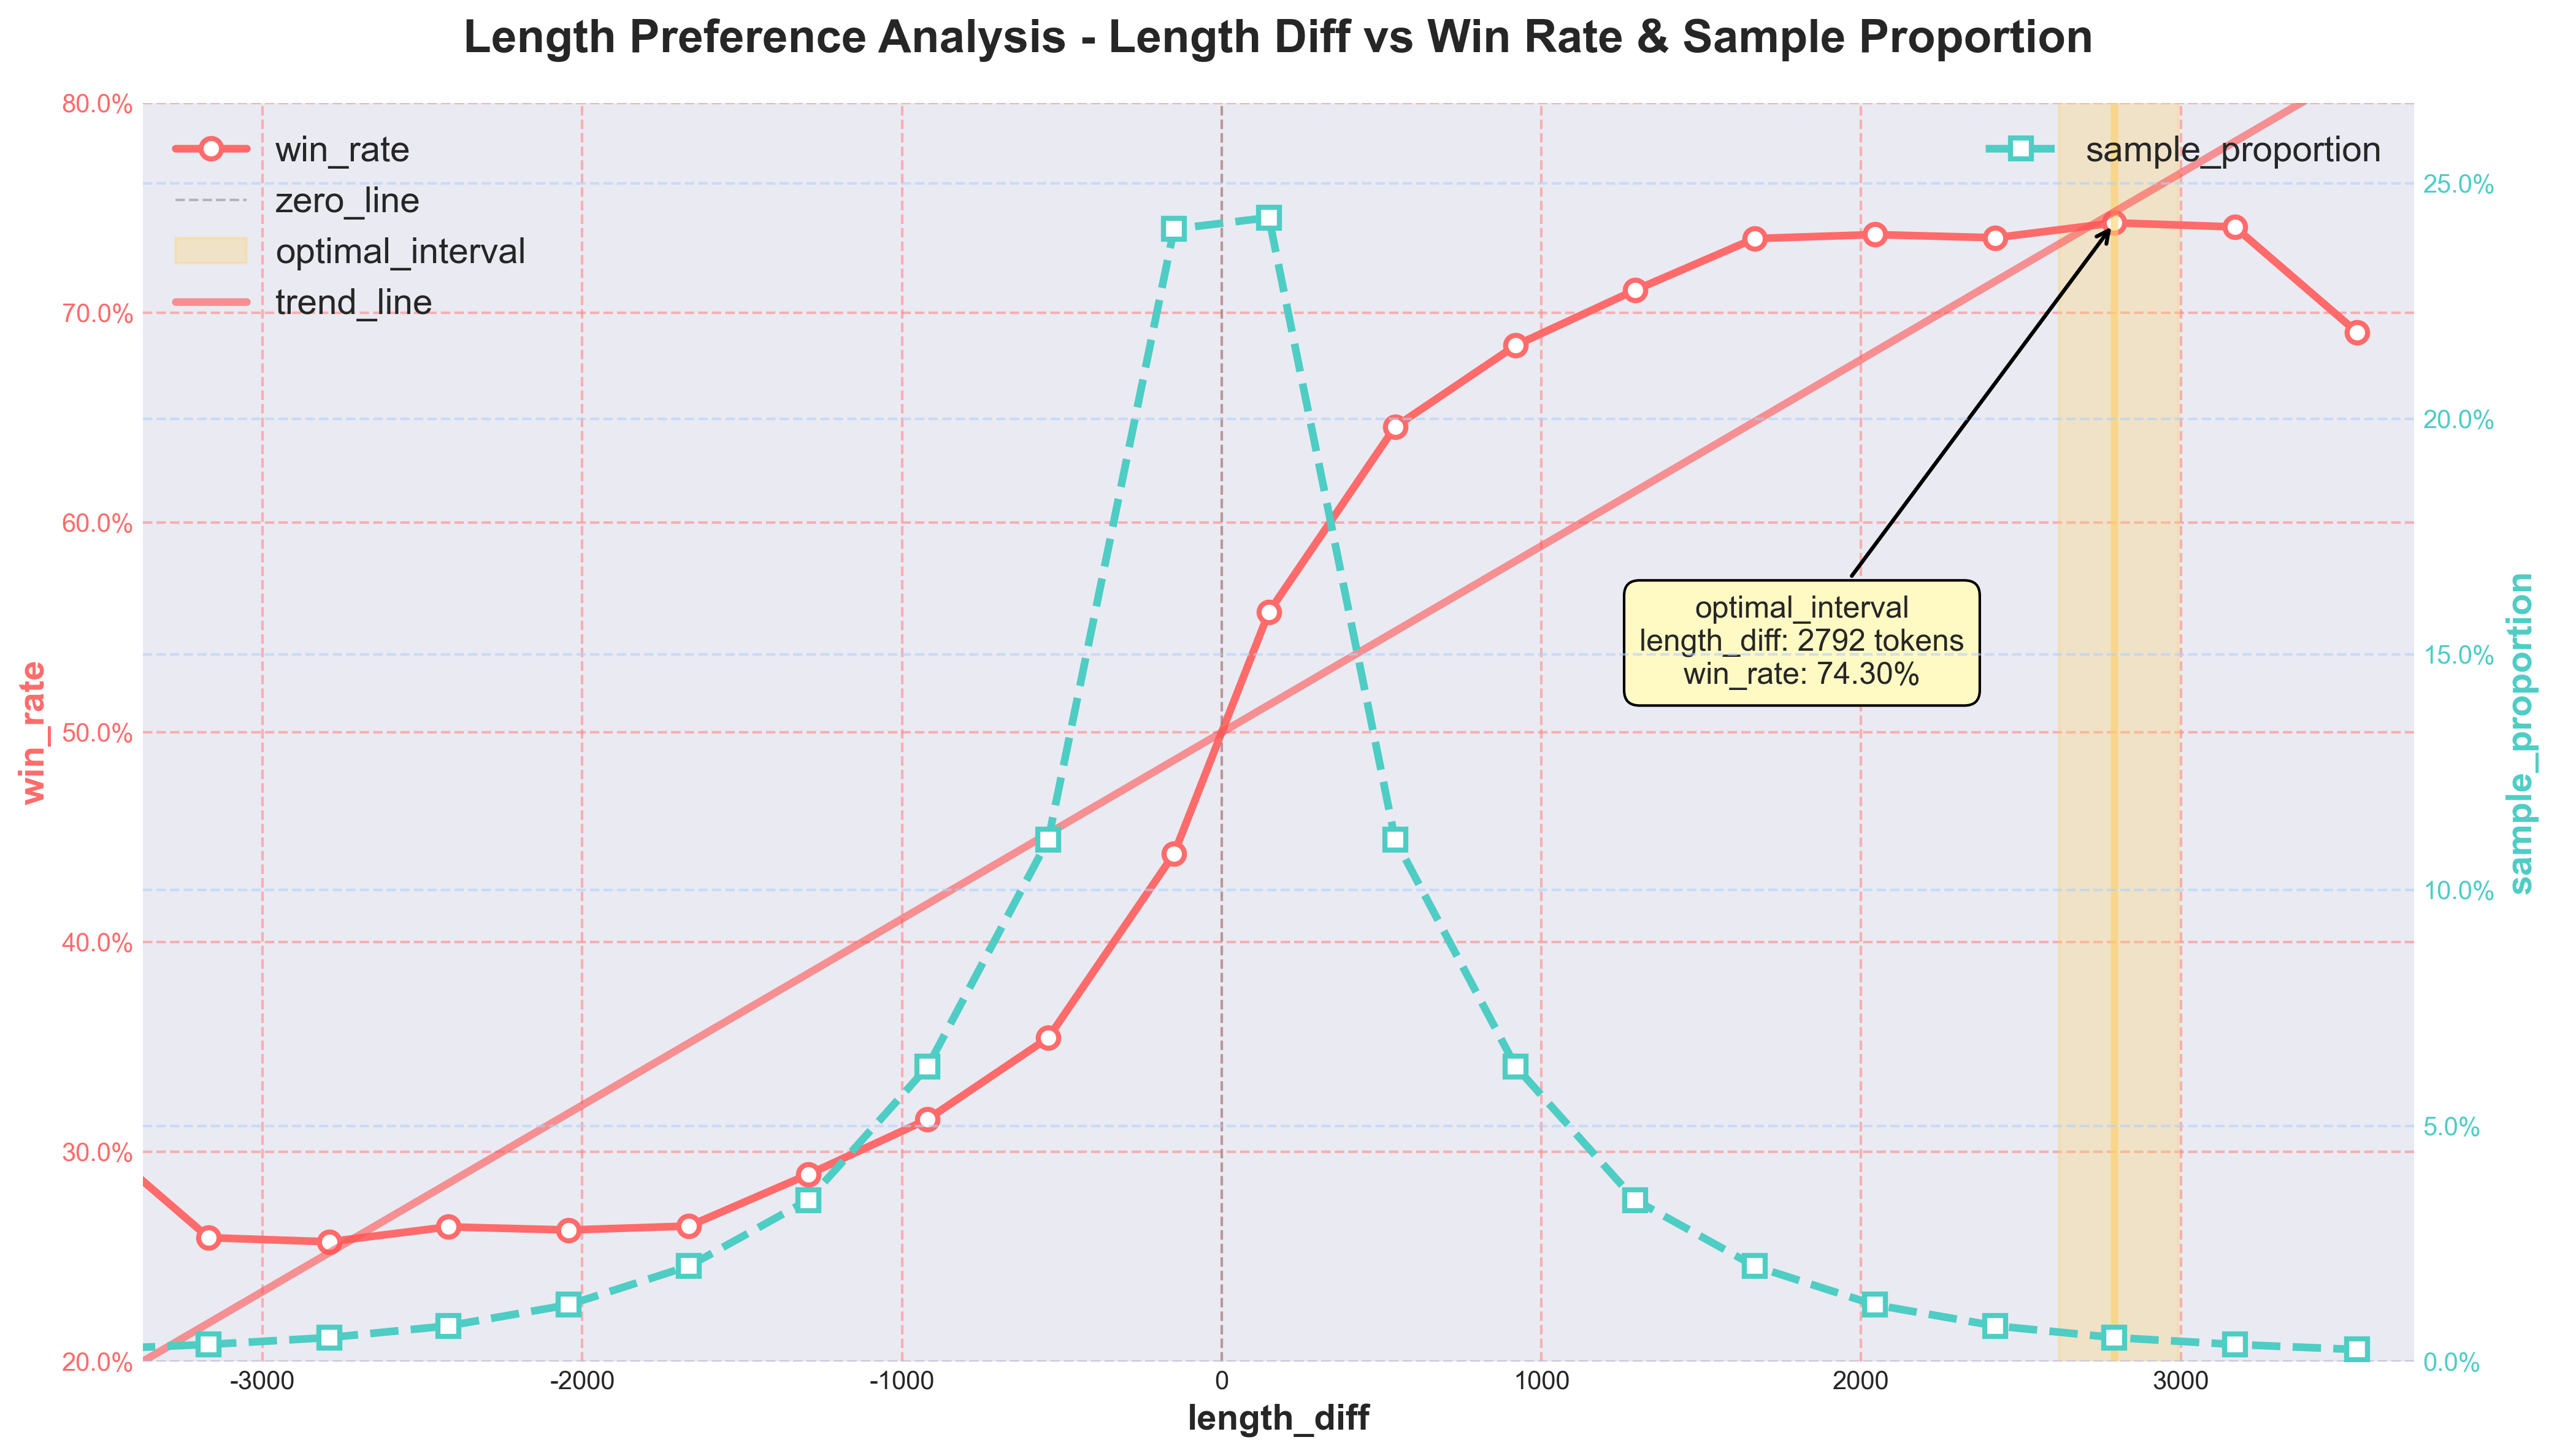

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C15_visualize_format_preference.py
格式偏好可视化分析
  数据加载成功，形状: 108,171 × 32

----------------------------------------
1. 全量数据分析
----------------------------------------
准备格式特征数据...
  原始行数: 108171 条评价
  过滤平局后: 78970 条有效评价 (过滤率: 27.0%)
  提取格式特征...
  解缠化后总样本数: 157940 个模型回答
  格式数据缓存已保存: d:\Files\MUC-QMJH\Data\format_data\format_data.parquet
分析 format_presence...

  格式存在性分析结果:
    has_format: 有格式=0.515 无格式=0.421 差异=+0.094
    has_header: 有格式=0.551 无格式=0.463 差异=+0.087
    has_list: 有格式=0.519 无格式=0.440 差异=+0.080
    has_bold: 有格式=0.531 无格式=0.420 差异=+0.111
分析 header_count...
  按样本数过滤: 164组 → 25组 (阈值: 200)
  分析分组数: 25
  总样本量: 157,940
  最优header_count: 21, win_rate: 0.594
分析 list_count...
  按样本数过滤: 433组 → 36组 (阈值: 1000)
  分析分组数: 36
  总样本量: 157,940
  最优list_count: 36, win_rate: 0.585
分析 bold_count...
  按样本数过滤: 456组 → 37组 (阈值: 1000)
  分析分组数: 37
  总样本量: 157,940
  最优bold_count: 36, win_rate: 0.596
分析 format_combination...
  分析分组数

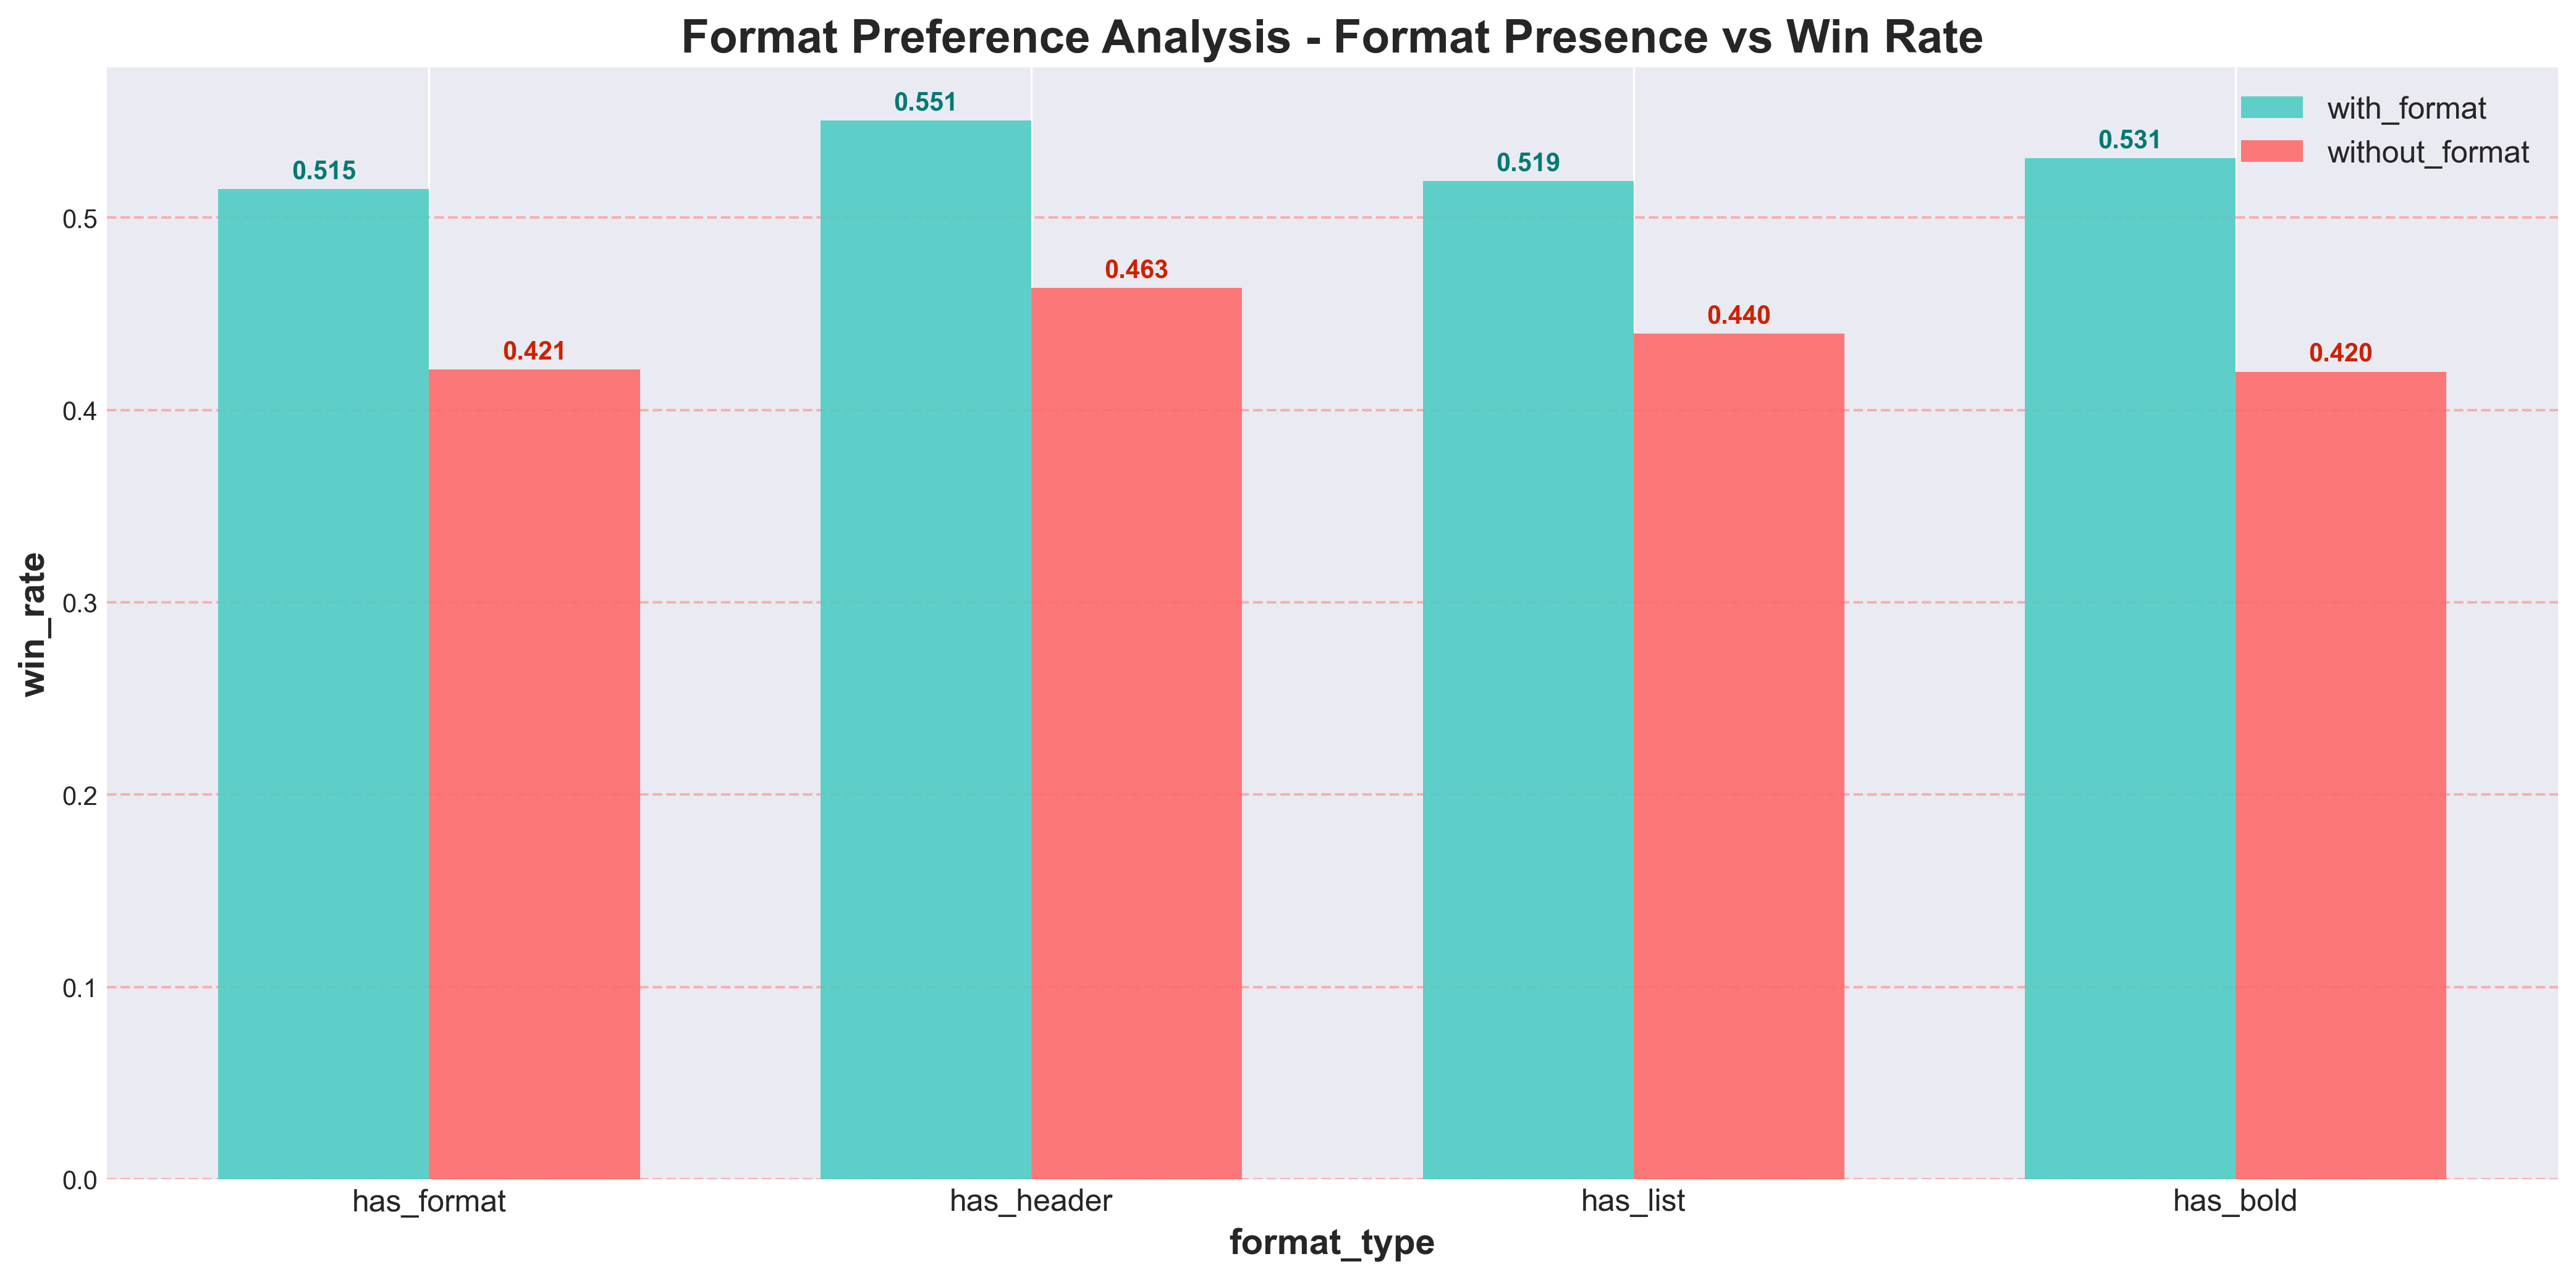

d:\Files\MUC-QMJH\Pictures\P07_header_count_line_chart.png


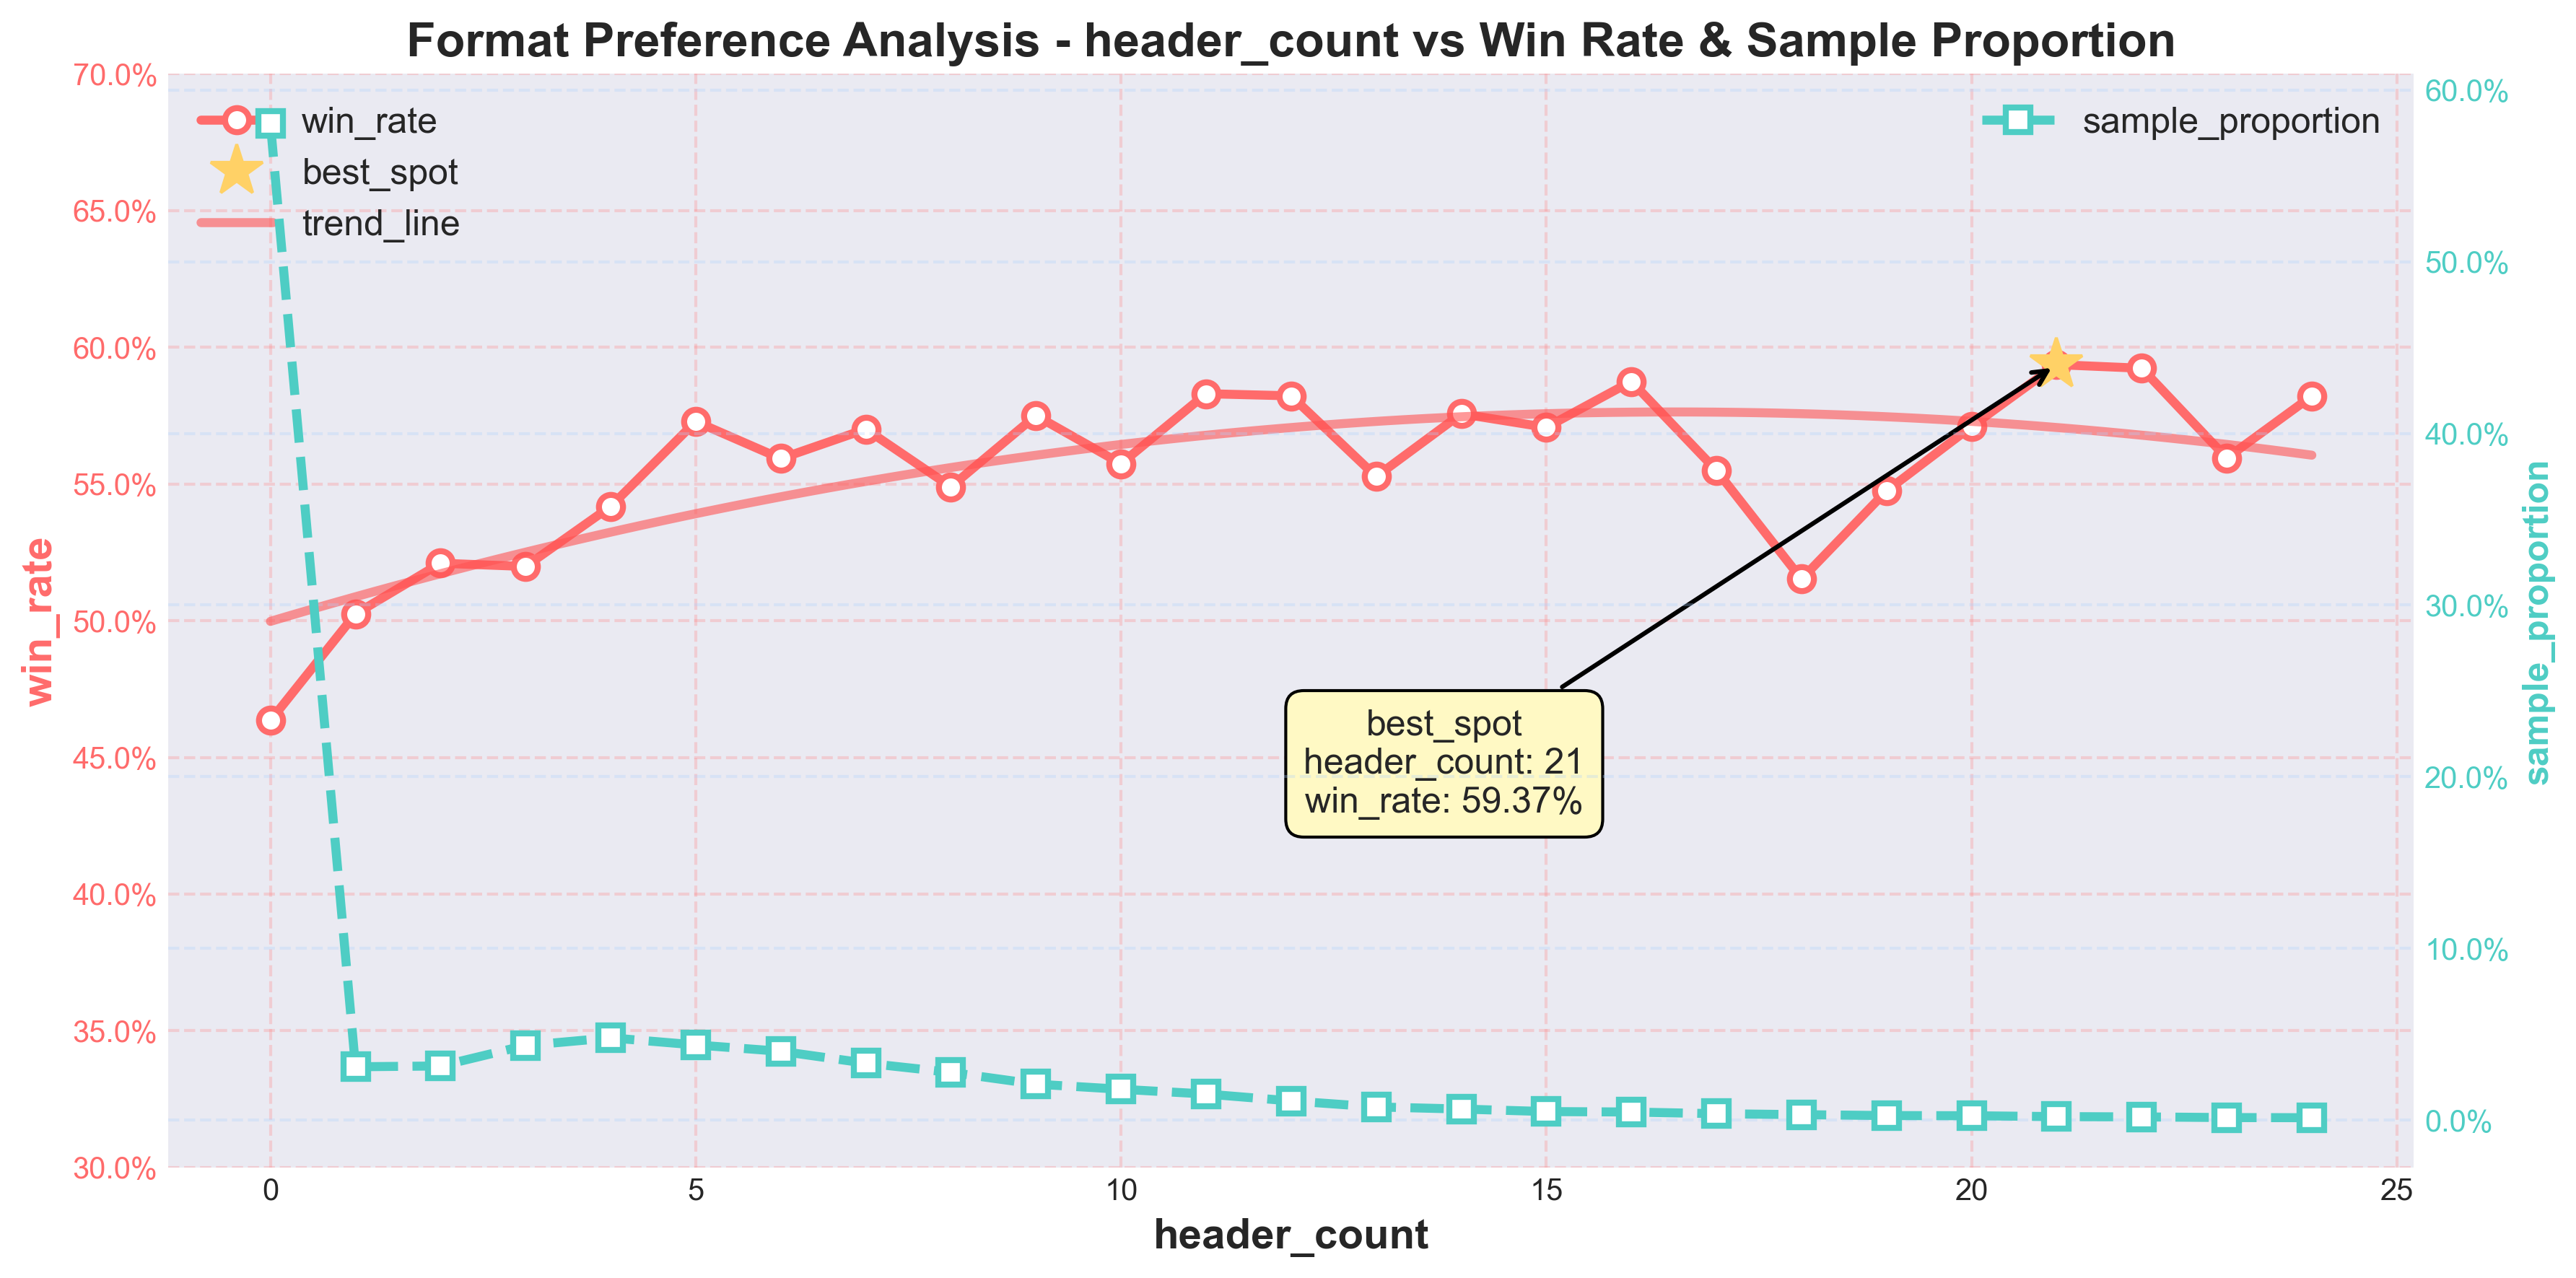

d:\Files\MUC-QMJH\Pictures\P08_list_count_line_chart.png


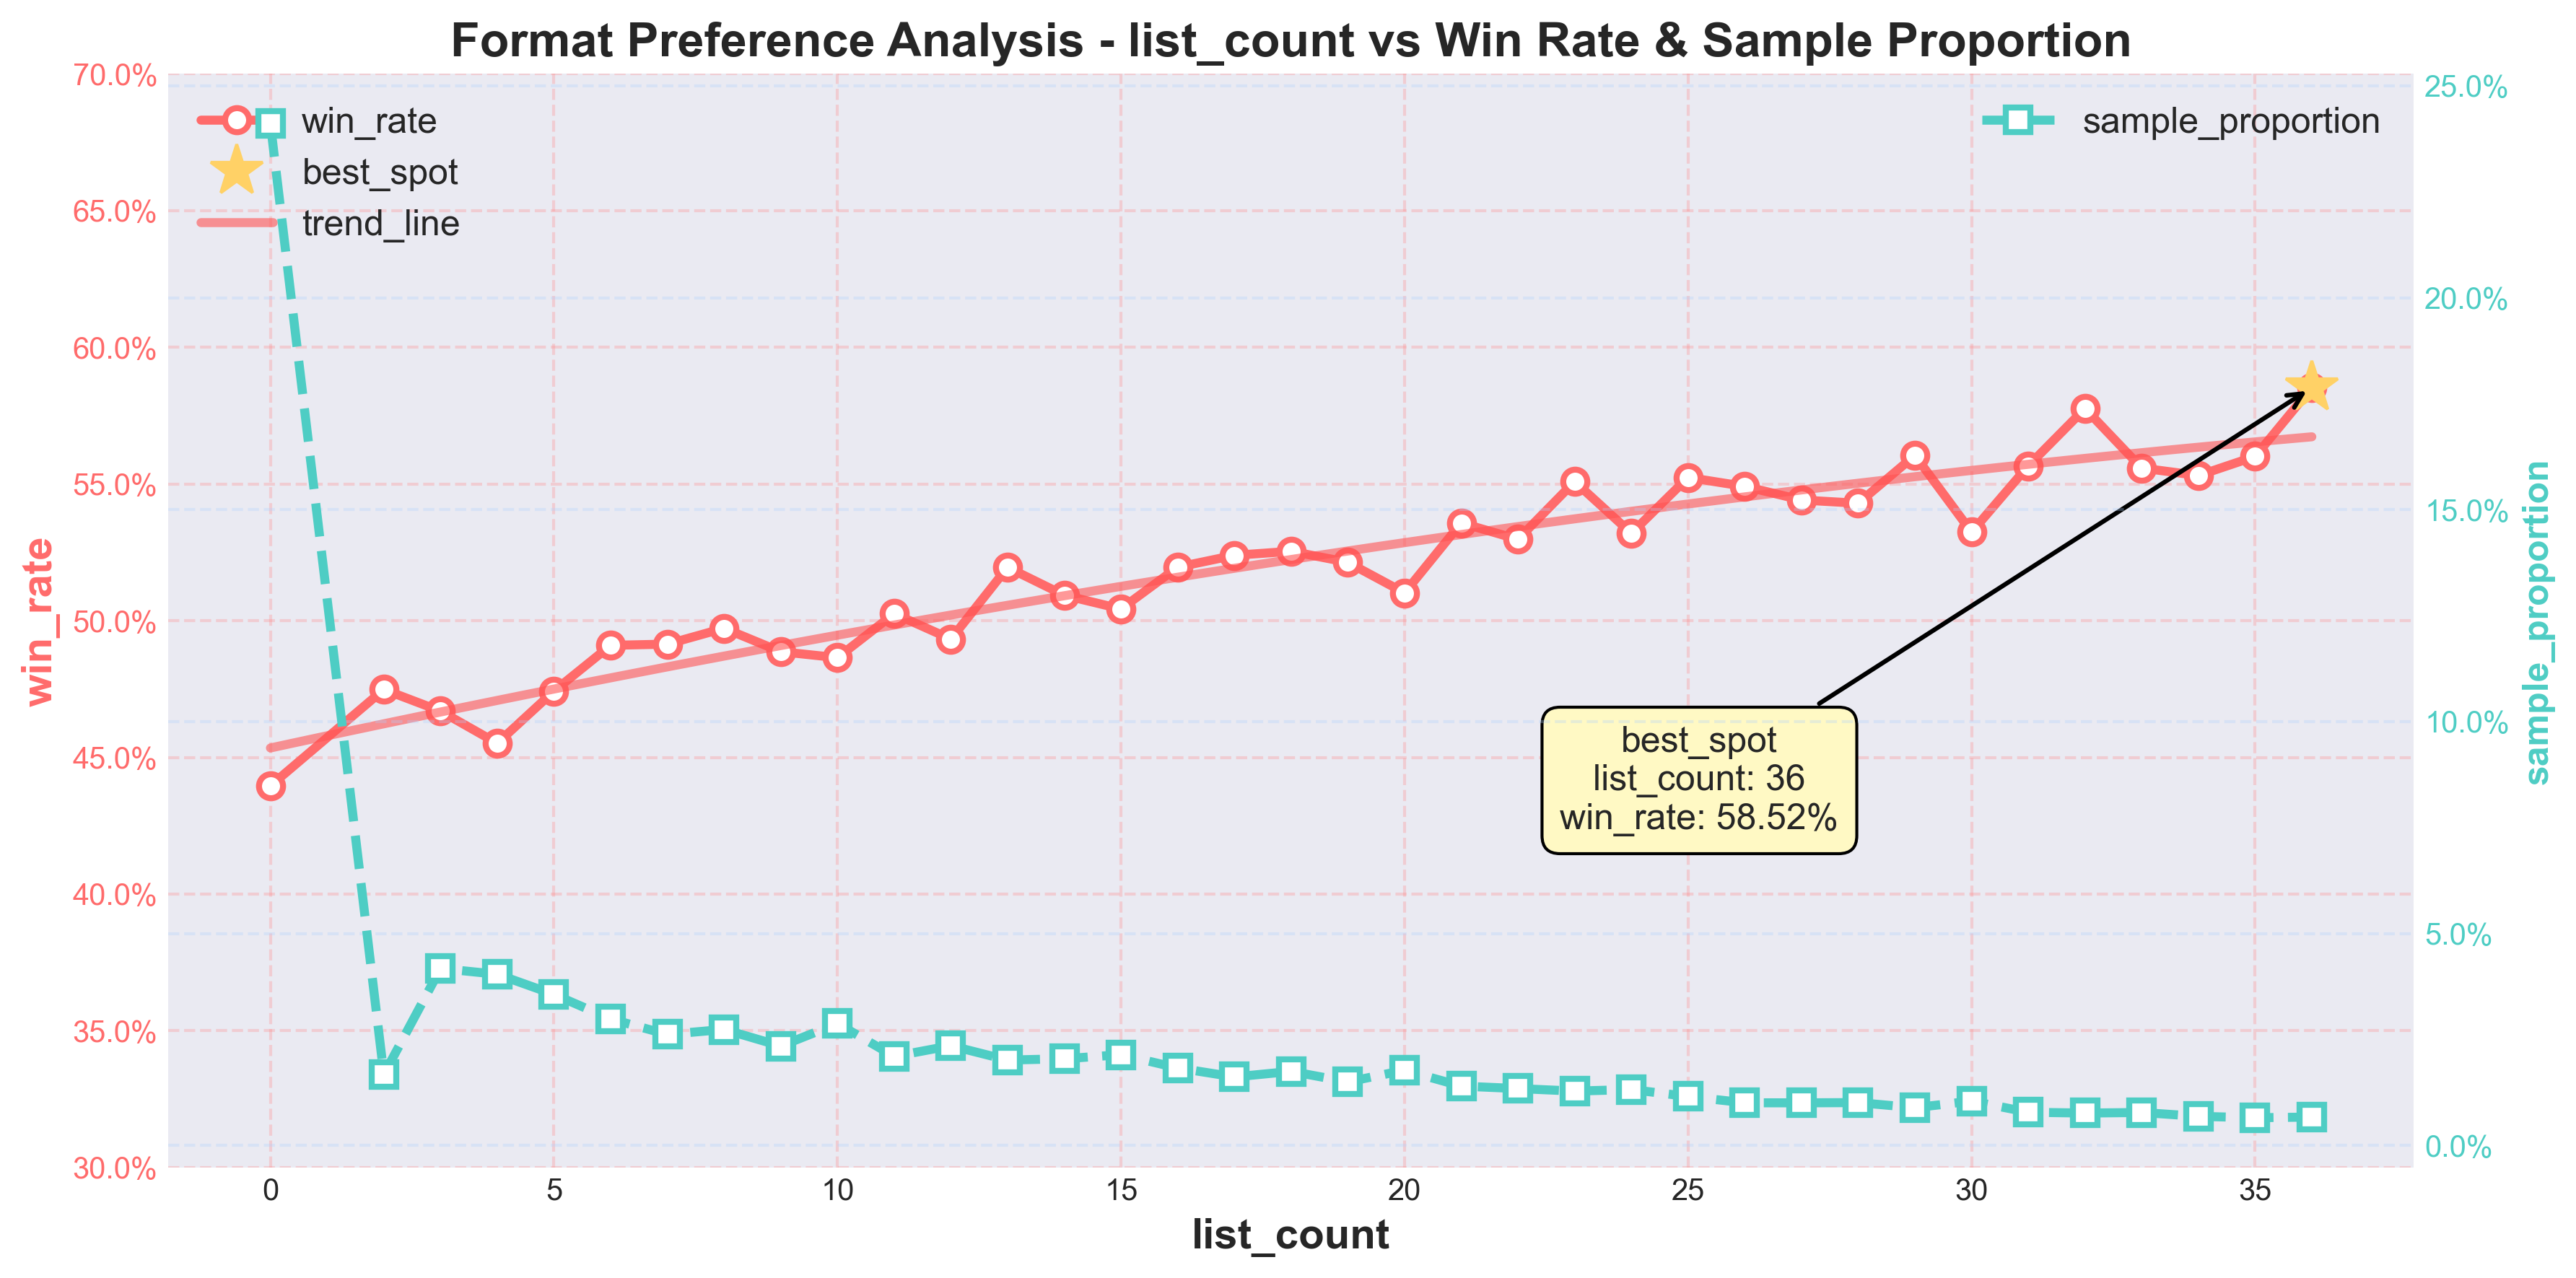

d:\Files\MUC-QMJH\Pictures\P09_bold_count_line_chart.png


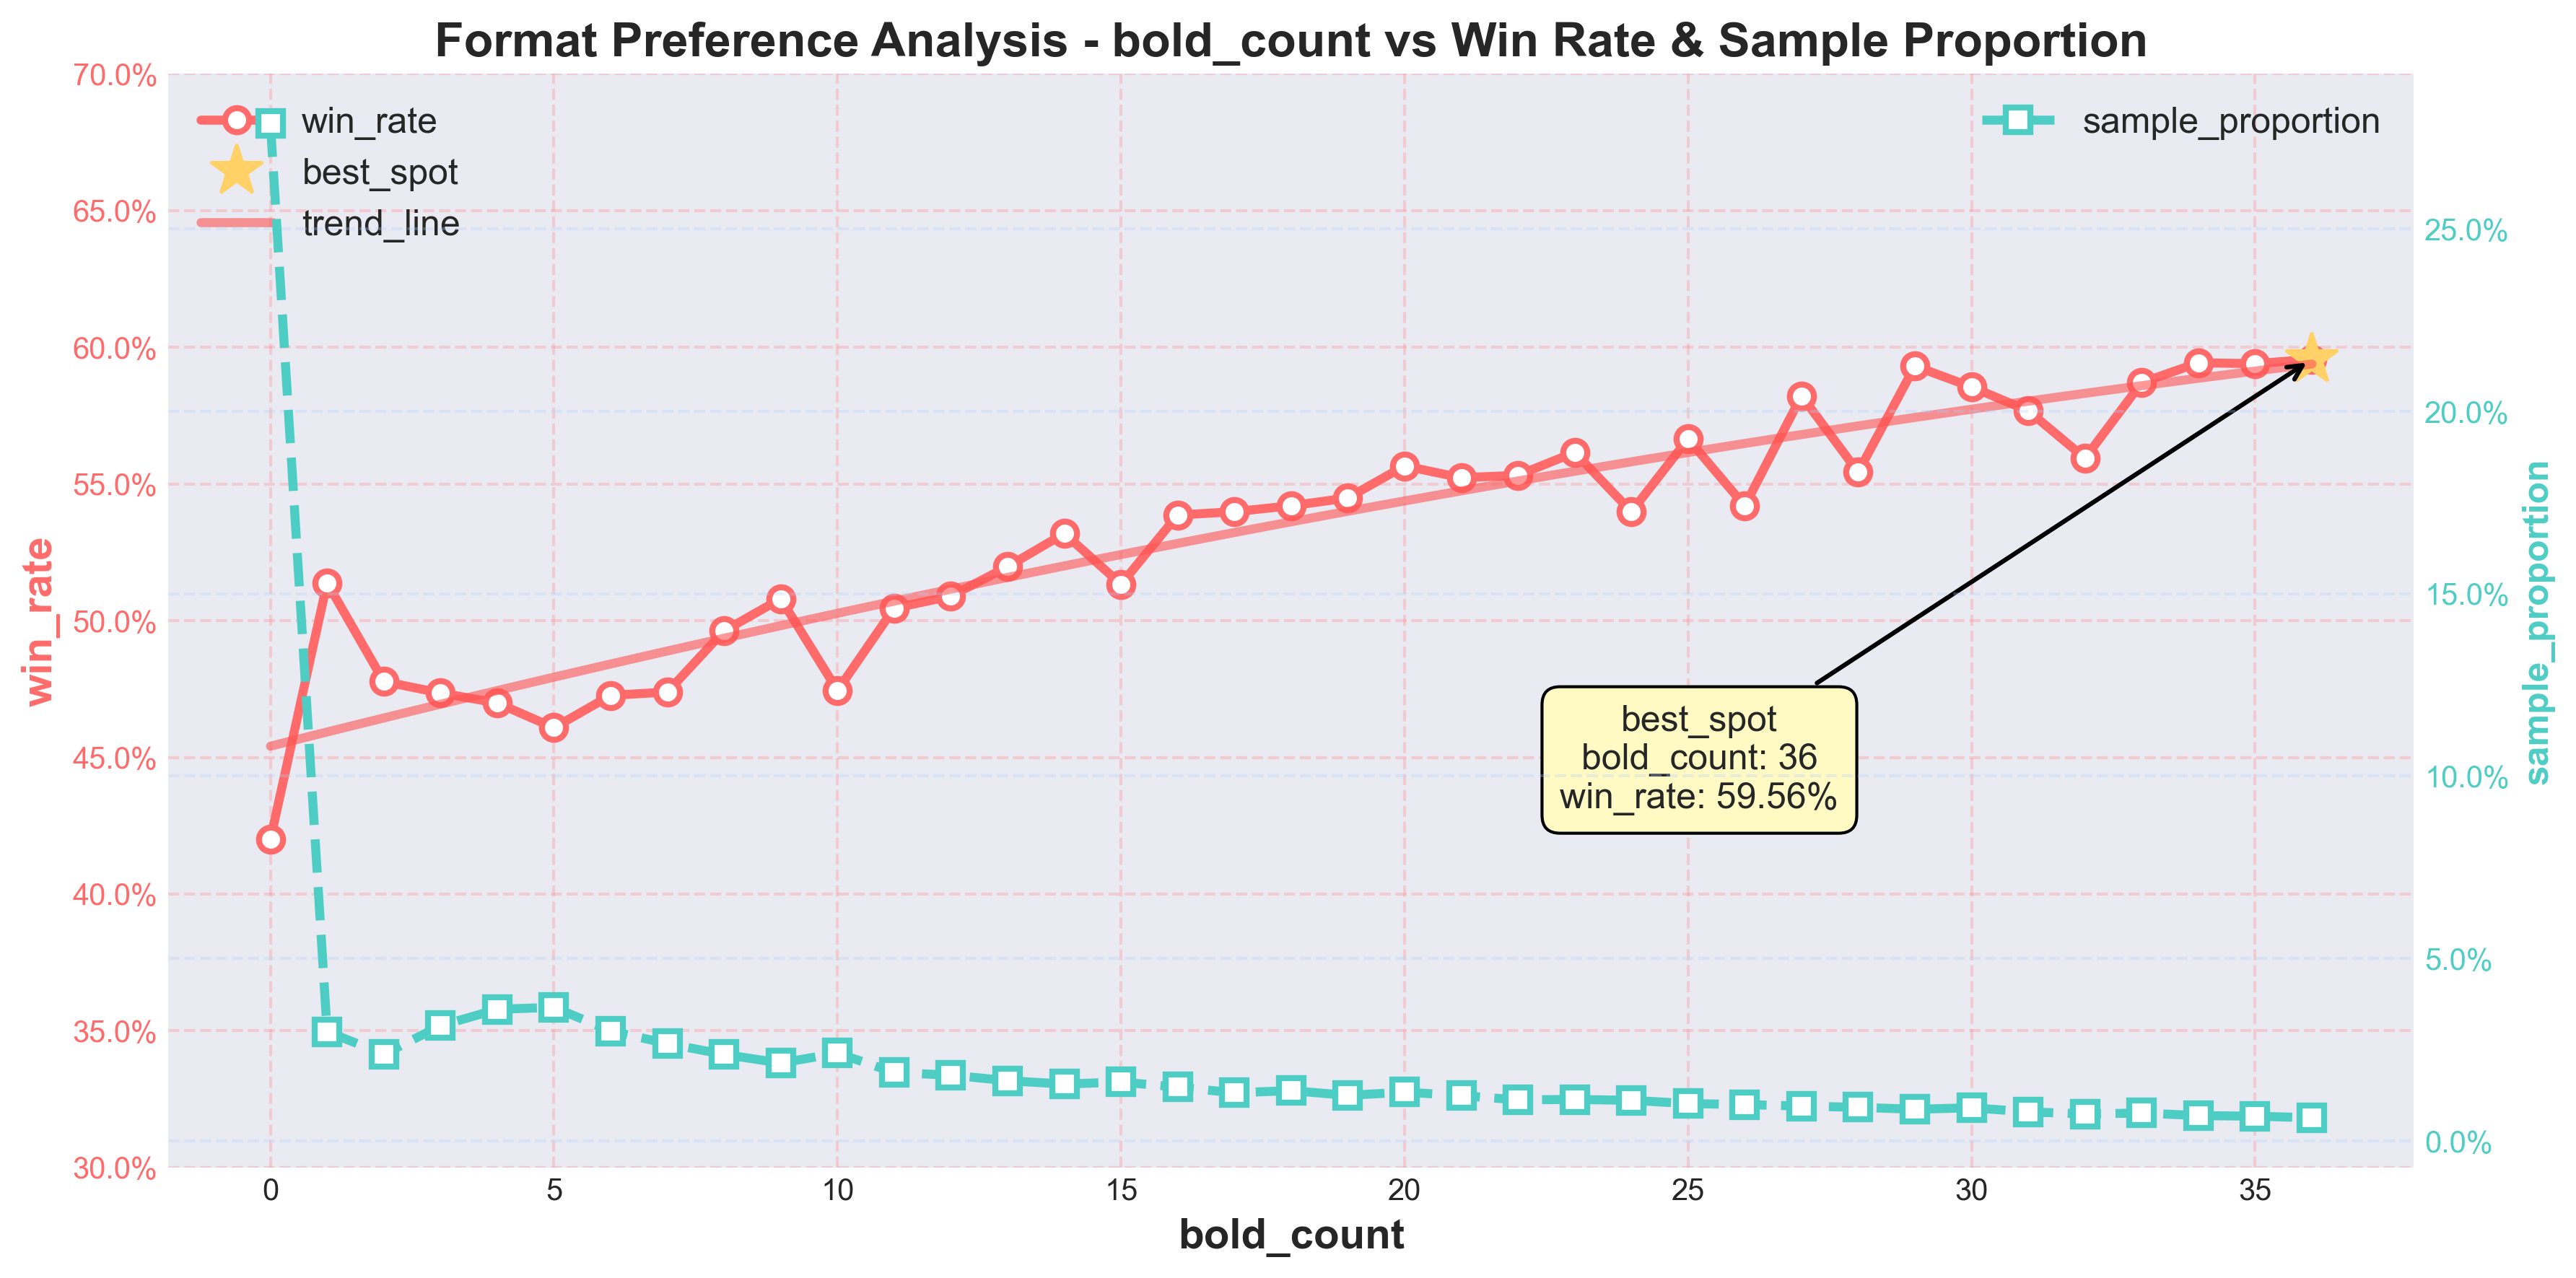

d:\Files\MUC-QMJH\Pictures\P10_format_combination_bar_chart.png


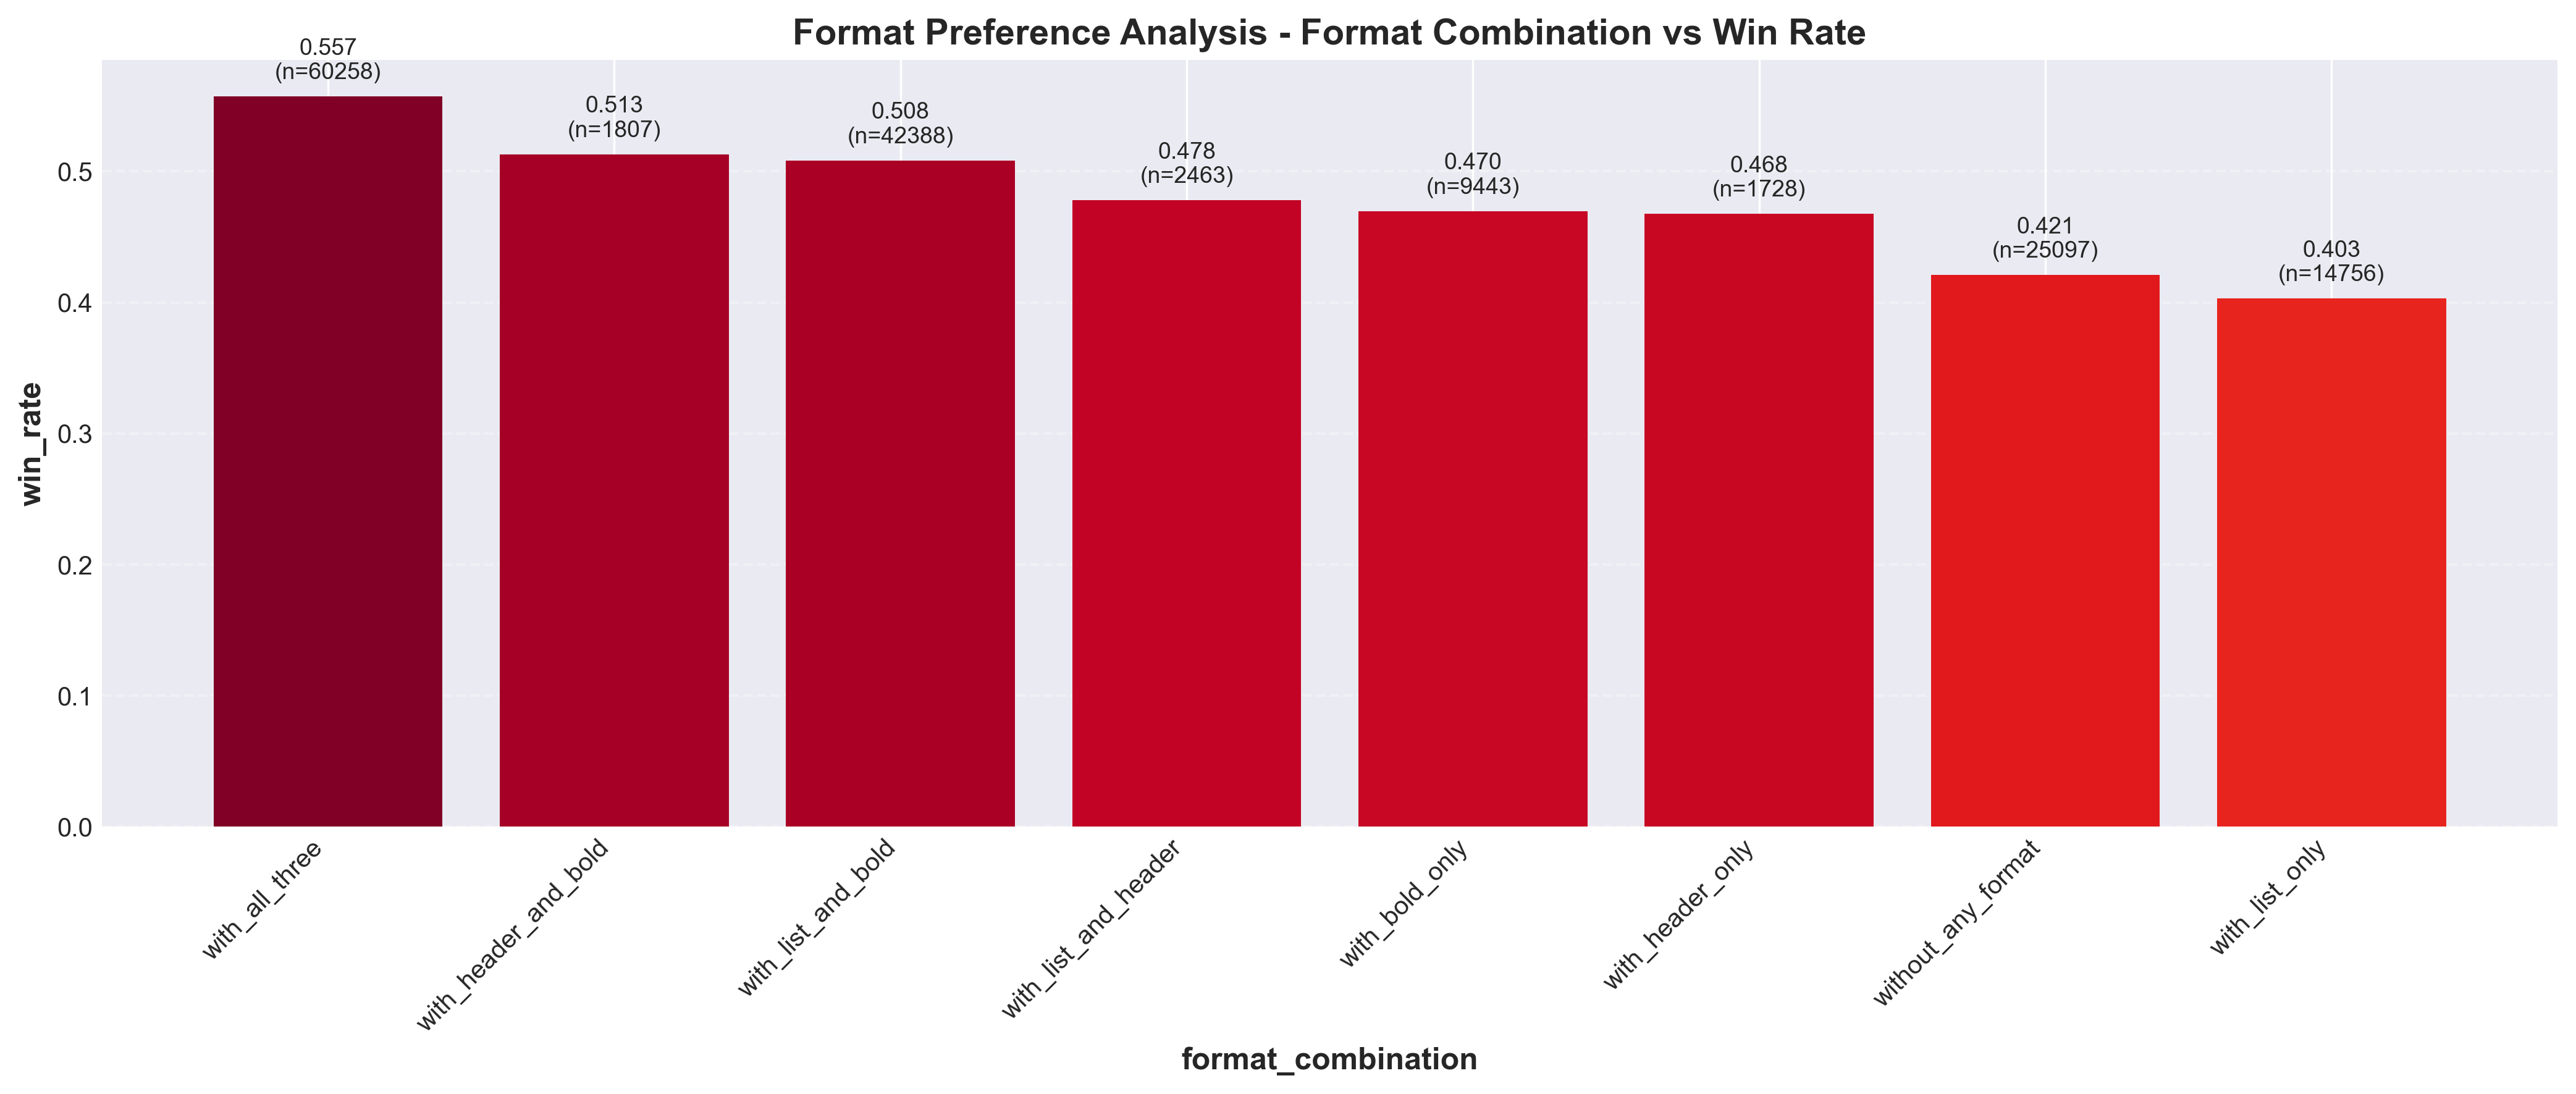

In [10]:
run_project_script("C13_divide_subset.py", max_output_lines=120)
show_text_file("Reports/R10_division_report.txt", max_lines=50)

subset_files = sorted(
    p.name for p in (project_root / "Data" / "optimized_data").glob("*_data.parquet")
)
print("Subset parquet files:")
for name in subset_files:
    print(" -", name)
print("Total subset-like parquet files:", len(subset_files))

run_project_script("C14_visualize_length_preference.py", max_output_lines=120)
show_text_file("Reports/R11_length_preference_report.txt", max_lines=40)
show_csv_file("Tables/T01_length_diff_analysis_stats.csv", max_rows=6)
show_image_file("Pictures/P05_length_diff_line_chart.png", width=900)

run_project_script("C15_visualize_format_preference.py", max_output_lines=140)
show_text_file("Reports/R12_format_preference_report.txt", max_lines=40)
show_csv_file("Tables/T04_format_presence_analysis.csv", max_rows=6)
show_csv_file("Tables/T08_format_combination_analysis.csv", max_rows=6)
for image_path in [
    "Pictures/P06_format_presence_bar_chart.png",
    "Pictures/P07_header_count_line_chart.png",
    "Pictures/P08_list_count_line_chart.png",
    "Pictures/P09_bold_count_line_chart.png",
    "Pictures/P10_format_combination_bar_chart.png",
]:
    show_image_file(image_path, width=900)

In [11]:
run_project_script("C16_length_test.py", max_output_lines=120)
show_text_file("Reports/R13_wilcoxon_length_test_report.txt", max_lines=60)

run_project_script("C17_format_test.py", max_output_lines=120)
show_text_file("Reports/R14_format_test_report.txt", max_lines=60)

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C16_length_test.py
C16  长度偏好统计检验（Wilcoxon 符号秩 + Bonferroni + rank-biserial r）

C16 长度偏好 Wilcoxon 符号秩检验

[全量]  总行数=108,171  读取完成

[无类别]  总行数=56,357  读取完成

[仅创意写作]  总行数=6,737  读取完成

[仅指令遵循]  总行数=7,016  读取完成

[仅数学]  总行数=5,357  读取完成

[仅代码]  总行数=20,788  读取完成

[创意+指令]  总行数=1,746  读取完成

[创意+数学]  总行数=31  读取完成
  [创意+数学] 有效对数 18 < 30，跳过

[创意+代码]  总行数=337  读取完成

[指令+数学]  总行数=1,298  读取完成

[指令+代码]  总行数=6,151  读取完成

[数学+代码]  总行数=1,327  读取完成

[创意+指令+数学]  总行数=16  读取完成
  [创意+指令+数学] 有效对数 11 < 30，跳过

[创意+指令+代码]  总行数=163  读取完成

[创意+数学+代码]  总行数=2  读取完成
  [创意+数学+代码] 有效对数 1 < 30，跳过

[指令+数学+代码]  总行数=841  读取完成

[四类全含]  总行数=4  读取完成
  [四类全含] 有效对数 3 < 30，跳过

报告已保存至: d:\Files\MUC-QMJH\Reports\R13_wilcoxon_length_test_report.txt

任务完成！

[stderr]
0.04s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modu

# Phase 5：净效应、稳健性、匹配诊断与机制解释（C18-C22）

这是最适合讲统计思维升级的一段。
学生会看到：

1. 描述性差异不等于净效应
2. 净效应不等于稳健结论
3. 稳健结论之后，还可以继续问“机制链条是什么”

其中 C20 与 C22 在 Notebook 默认使用 fast mode 参数，目的是让课堂演示能在合理时间内完成；如果要正式复现结果，可把上面的 FAST_MODE 改为 False 再重跑。

In [12]:
run_project_script("C18_pure_effect.py", max_output_lines=140)
show_text_file("Reports/R16_pure_effect_report.txt", max_lines=60)

run_project_script("C19_length_effect_robust.py", max_output_lines=140)
show_text_file("Reports/R17_length_effect_robust_report.txt", max_lines=60)
show_csv_file("Tables/T14_length_robust_summary.csv", max_rows=6)

c20_args = ["--bootstrap", str(C20_BOOTSTRAP)]
print("C20 args:", c20_args)
run_project_script("C20_format_effect_robust.py", args=c20_args, max_output_lines=140)
show_text_file("Reports/R18_format_effect_robust_report.txt", max_lines=60)
show_csv_file("Tables/T15_format_robust_summary.csv", max_rows=6)

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C18_pure_effect.py


步骤 1/5：加载全量 optimized_data（仅用于全局模型统计量计算）
  全量有效配对行数：78,970
步骤 2/5：计算全局模型统计量（胜率 / 词冗性 / 格式风格）
  模型总数：52
步骤 3/5：验证模型能力−长度/格式共线性
步骤 4/5：逐子集加载 C13 数据并运行长度嵌套模型（M0→M3）
  1/17: 全量
  2/17: 无类别
  3/17: 仅创意写作
  4/17: 仅指令遵循
  5/17: 仅数学
  6/17: 仅代码
  7/17: 创意+指令
  8/17: 创意+数学
  9/17: 创意+代码
  10/17: 指令+数学
  11/17: 指令+代码
  12/17: 数学+代码
  13/17: 创意+指令+数学
  14/17: 创意+指令+代码
  15/17: 创意+数学+代码
  16/17: 指令+数学+代码
    [警告] Logit 拟合失败: Singular matrix
  17/17: 四类全含
步骤 5/5：逐子集运行格式嵌套模型（F0→F3）
  1/17: 全量（格式）
  2/17: 无类别（格式）
  3/17: 仅创意写作（格式）
  4/17: 仅指令遵循（格式）
  5/17: 仅数学（格式）
  6/17: 仅代码（格式）
  7/17: 创意+指令（格式）
  8/17: 创意+数学（格式）
  9/17: 创意+代码（格式）
  10/17: 指令+数学（格式）
  11/17: 指令+代码（格式）
  12/17: 数学+代码（格式）
  13/17: 创意+指令+数学（格式）
  14/17: 创意+指令+代码（格式）
  15/17: 创意+数学+代码（格式）
  16/17: 指令+数学+代码（格式）
    [警告] Logit 拟合失败: Singular matrix
  17/17: 四类全含（格式）

[stderr]
0.04s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s 

RuntimeError: C18_pure_effect.py failed with exit code 1

Running: C:\Code\Anaconda3\envs\muc-qmjh\python.exe d:\Files\MUC-QMJH\Codes\C21_enhanced_matching_diagnostics.py
1/3 读取全量数据并准备子集
2/3 执行匹配诊断
诊断子集：全量
诊断子集：无类别
诊断子集：仅创意写作
诊断子集：仅指令遵循
诊断子集：仅数学
诊断子集：仅代码
诊断子集：创意+指令
诊断子集：创意+代码
诊断子集：指令+数学
诊断子集：指令+代码
诊断子集：数学+代码
诊断子集：指令+数学+代码
匹配诊断报告（R19）

【诊断标准】
  - 处理变量与混淆变量口径完全复用 C19
  - 平衡性指标：标准化均值差 SMD，经验阈值 |SMD| < 0.1
  - 匹配：1:1 最近邻，有放回，caliper = 0.2 * SD(logit_ps)
  - 显著性：匹配后 winner_a 的配对 Wilcoxon 检验


--------------------------------------------------------------------------------
【全量】n = 78,783
  匹配对数：39237（treated match rate=100.00%）
  caliper(logit_ps)：0.371321
  公共支持区间：[0.0100, 0.9900]，覆盖率=100.00%
  平衡性改善：max|SMD| 1.4732 → 0.1765，mean|SMD| 0.2502 → 0.0597
  匹配后 ATE：0.1601；配对 Wilcoxon p=0

--------------------------------------------------------------------------------
【无类别】n = 41,610
  匹配对数：20723（treated match rate=100.00%）
  caliper(logit_ps)：0.386814
  公共支持区间：[0.0112, 0.9900]，覆盖率=99.54%
  平衡性改善：max|SMD| 1.4804 → 0.2914，mean|SMD| 0.3449 → 0.0915
  匹配后

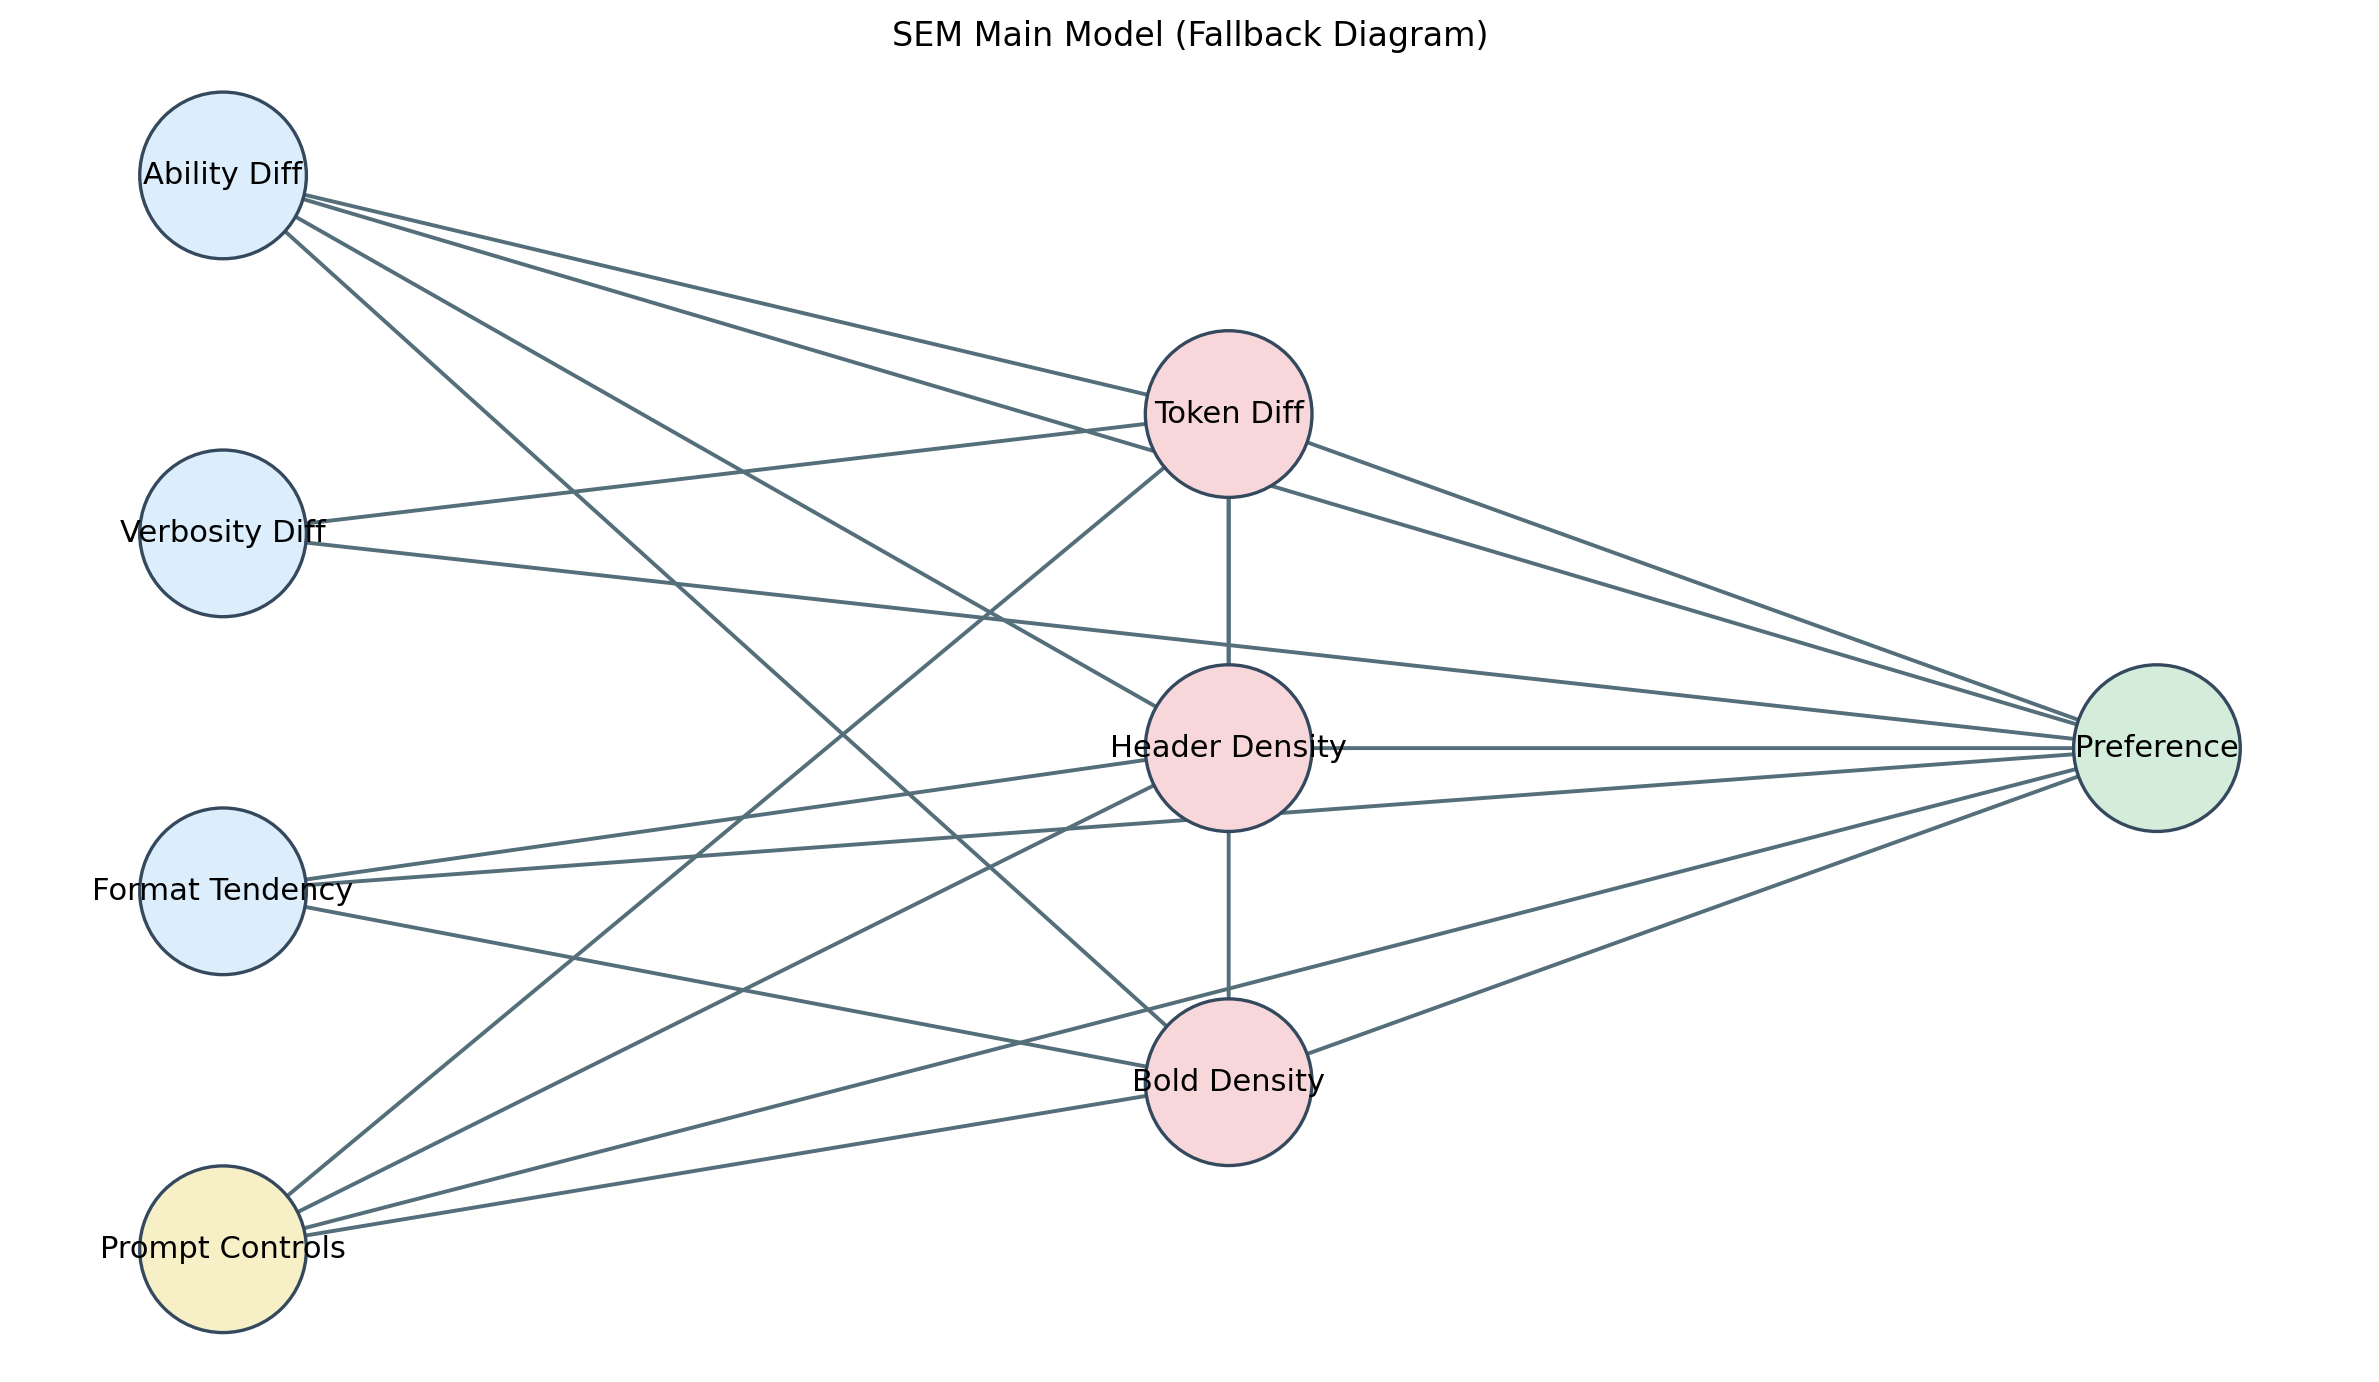

In [ ]:
run_project_script("C21_enhanced_matching_diagnostics.py", max_output_lines=140)
show_text_file("Reports/R19_enhanced_diagnostics_report.txt", max_lines=60)
show_csv_file("Tables/T16_matching_summary.csv", max_rows=6)
show_csv_file("Tables/T17_matching_balance.csv", max_rows=6)

c22_args = ["--bootstrap", str(C22_BOOTSTRAP)]
if C22_MAX_N is not None:
    c22_args.extend(["--max-n", str(C22_MAX_N)])
print("C22 args:", c22_args)
run_project_script("C22_sem_analysis.py", args=c22_args, max_output_lines=180)
show_text_file("Reports/R20_sem_analysis_report.txt", max_lines=80)
show_csv_file("Tables/T11_sem_model_comparison.csv", max_rows=6)
show_csv_file("Tables/T13_sem_bootstrap_effects_ci.csv", max_rows=6)
show_image_file("Pictures/P11_sem_path_diagram.png", width=1000)

# 收束：如何用这一份 Notebook 讲完整个研究工程

如果面对的是没有统计背景的学生，建议按下面的顺序推进：

1. 先讲数据对象，而不是先讲模型
2. 先讲工程清洗为什么必要，再讲统计检验为什么必要
3. 先让学生看图和表，再解释 p 值、效应量、稳健性与机制链条
4. 反复强调：研究不是“跑一个显著结果”，而是逐层排除误解、逐层提高解释可信度

Notebook 使用建议：

- 课堂演示：保持 FAST_MODE = True
- 结果复现：改为 FAST_MODE = False 后，从 C18 开始重跑高耗时部分
- 若只想讲方法链，可以直接跳到对应 Phase；若想展示研究严谨性，则按 C01-C22 全顺序执行